In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import *

In [4]:
data = datasets.load_breast_cancer()

In [5]:
X = data.data[:,:2]
y = data.target

In [6]:
df = pd.DataFrame(data.data[:,:2], columns=data.feature_names[:2])
df['target'] = data.target
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

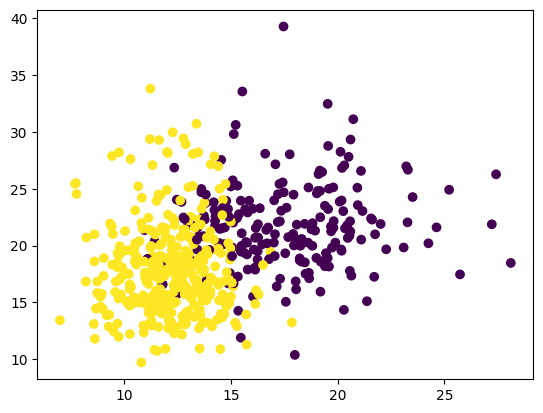

In [11]:
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=y)

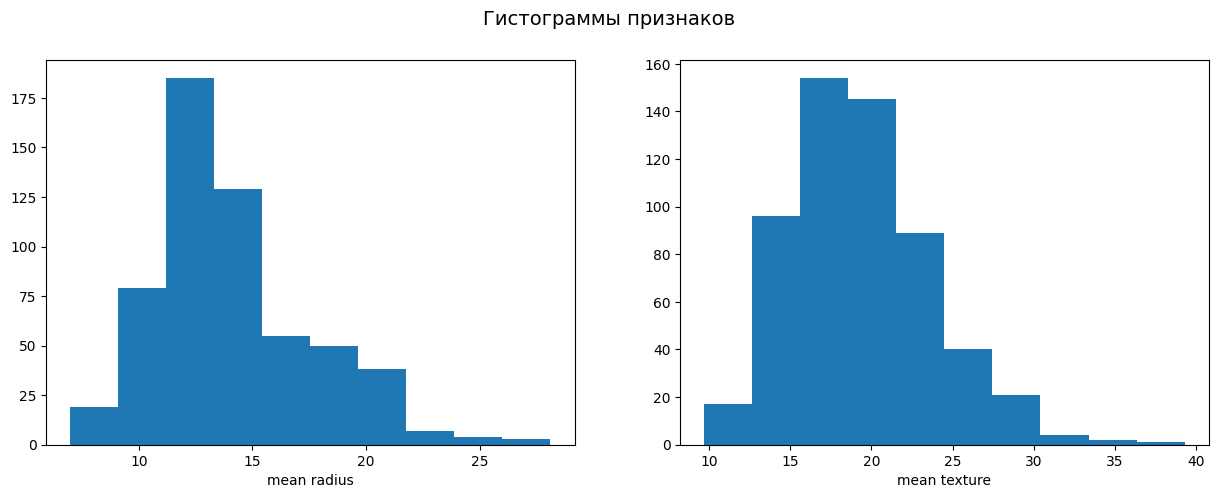

In [12]:
plt.figure(figsize=(15, 5))
for i in range(2):    
    plt.subplot(1, 2, i+1)
    plt.hist(X[:, i])
    plt.xlabel(data.feature_names[i])
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

In [14]:
from sklearn.naive_bayes import GaussianNB

In [15]:
gaussian_nb = GaussianNB()

In [16]:
gaussian_nb.fit(X, y)

,priors,None
,var_smoothing,1e-09


In [17]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

In [18]:
Z = gaussian_nb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

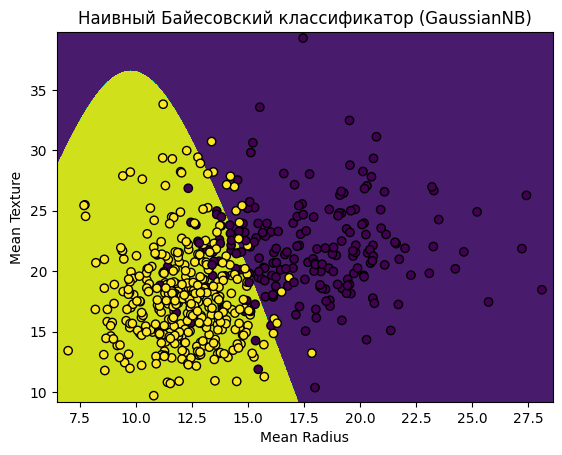

In [23]:
plt.contourf(xx, yy, Z)
plt.scatter(X[:, 0], X[:, 1], edgecolors='black', c=y)
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.title('Наивный Байесовский классификатор (GaussianNB)')
plt.show()

In [24]:
y_pred = gaussian_nb.predict(X)

In [25]:
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[164  48]
 [ 17 340]]
Accuracy=  0.8857644991212654
F1_score=  0.912751677852349


In [26]:
X = data.data
y = data.target
X.shape, y.shape

((569, 30), (569,))

In [27]:
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


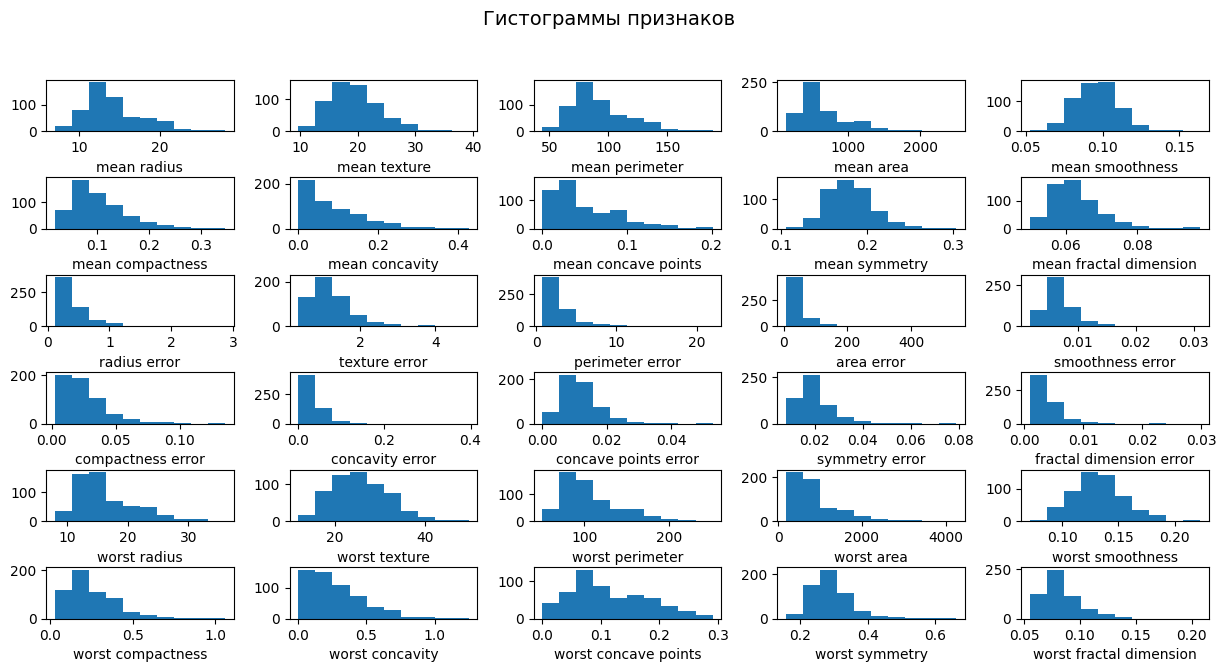

In [28]:
f = plt.figure(figsize=(15, 7))
for i in range(30):
    plt.subplot(6, 5, i+1)
    plt.hist(X[:, i])
    
    plt.xlabel(data.feature_names[i])
f.subplots_adjust(hspace=0.9,wspace=0.3)    
plt.suptitle('Гистограммы признаков',fontsize=14)
plt.show()

In [36]:
data = datasets.load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df = df.drop(['mean concavity', 'radius error', 'texture error',
              'perimeter error', 'area error', 'smoothness error',
              'compactness error', 'concavity error', 'concave points error',
              'symmetry error', 'fractal dimension error', 'worst area',
              'worst concavity'], axis=1)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concave points,mean symmetry,mean fractal dimension,worst radius,worst texture,worst perimeter,worst smoothness,worst compactness,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.14710,0.2419,0.07871,25.38,17.33,184.60,0.1622,0.6656,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.07017,0.1812,0.05667,24.99,23.41,158.80,0.1238,0.1866,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.12790,0.2069,0.05999,23.57,25.53,152.50,0.1444,0.4245,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.10520,0.2597,0.09744,14.91,26.50,98.87,0.2098,0.8663,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.10430,0.1809,0.05883,22.54,16.67,152.20,0.1374,0.2050,0.1625,0.2364,0.07678,0


In [37]:
gaussian_nb.fit(X, y)
y_pred = gaussian_nb.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy= ', accuracy_score(y, y_pred))
print('F1_score= ', f1_score(y, y_pred))

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


## Практичская работа

### 1. Другие вариации модели наивного Байеса

In [75]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Binarizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB, CategoricalNB

In [42]:
data = datasets.load_breast_cancer()
X = data.data
y = data.target

In [44]:
X_scaled = MinMaxScaler().fit_transform(X)

In [47]:
X_bin = Binarizer(threshold=0.5).fit_transform(X_scaled)

In [54]:
models = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'ComplementNB': ComplementNB()
}

In [55]:
for name, model in models.items():
    if name == 'BernoulliNB':
        model.fit(X_bin, y)
        score = model.score(X_bin, y)
    else:
        model.fit(X_scaled, y)
        score = model.score(X_scaled, y)
    print(f"{name} | {score:.4f}")


GaussianNB | 0.9402
MultinomialNB | 0.8383
BernoulliNB | 0.8981
ComplementNB | 0.8524


- **GaussianNB** — лучший результат (**94%**), так как признаки непрерывные
- **BernoulliNB** — 89.8%, работает с бинарными данными
- **ComplementNB** — 85.2%, уступает GaussianNB
- **MultinomialNB** — 83.8%, хуже всех для данного типа данных

Для breast cancer оптимальна **GaussianNB**, остальные модели требуют преобразований и дают худший результат.

### 2. Титаник

In [61]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [58]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']].copy()
df.dropna(inplace=True)

In [62]:
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

In [63]:
X_scaled = MinMaxScaler().fit_transform(X)

In [64]:
X_bin = (X_scaled > 0.5).astype(int)

In [65]:
models = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB()
}

In [66]:
for name, model in models.items():
    if name == 'BernoulliNB':
        model.fit(X_bin, y)
        score = model.score(X_bin, y)
    else:
        model.fit(X_scaled, y)
        score = model.score(X_scaled, y)
    print(f"{name} | {score:.4f}")

GaussianNB | 0.7731
MultinomialNB | 0.6625
BernoulliNB | 0.7801


### 3. Приминяем наивный байесовский классификатор

In [68]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [69]:
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Survived']].copy()
df.dropna(inplace=True)

In [70]:
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])

X = df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]
y = df['Survived']

In [71]:
X_scaled = MinMaxScaler().fit_transform(X)

In [72]:
X_bin = (X_scaled > 0.5).astype(int)

In [73]:
X_cat = X.copy()
for col in X_cat.columns:
    X_cat[col] = LabelEncoder().fit_transform(X_cat[col])

In [76]:
models = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'CategoricalNB': CategoricalNB()
}

In [77]:
for name, model in models.items():
    try:
        if name == 'BernoulliNB':
            model.fit(X_bin, y)
            score = model.score(X_bin, y)
        elif name == 'CategoricalNB':
            model.fit(X_cat, y)
            score = model.score(X_cat, y)
        else:
            model.fit(X_scaled, y)
            score = model.score(X_scaled, y)
        print(f"{name} | {score:.4f}")
    except Exception as e:
        print(f"{name} | Ошибка: {str(e)[:30]}")

GaussianNB | 0.7823
MultinomialNB | 0.6798
BernoulliNB | 0.7879
CategoricalNB | 0.8638


На Титанике лучший результат показал **CategoricalNB (86.4%)**, так как большинство признаков (Pclass, Sex, Embarked) категориальные.  
**BernoulliNB** и **GaussianNB** дали ~78-79%, а **MultinomialNB** — всего 68%.  
Выбор модели должен соответствовать типу данных: категориальные → CategoricalNB, непрерывные → GaussianNB, бинарные → BernoulliNB.